In [1]:
pip install opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
def display_image(image_array, title='', cmap='gray'):
    """Отображает изображение с помощью matplotlib"""
    plt.figure(figsize=(8, 6))
    plt.imshow(image_array, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_images(image_arrays, titles=None, cols=3, cmap='gray', figsize=(15, 10)):
    """
    Отображает несколько изображений в виде сетки.

    Параметры:
        image_arrays : list of numpy.ndarray
            Список массивов изображений (в формате HWC или HW).
        titles : list of str, optional
            Заголовки для каждого изображения (должен совпадать с image_arrays по длине).
        cols : int, optional
            Количество столбцов в сетке (по умолчанию 3).
        cmap : str, optional
            Цветовая карта (по умолчанию 'gray' для ч/б изображений).
        figsize : tuple, optional
            Размер фигуры (ширина, высота) в дюймах (по умолчанию (15, 10)).
    """
    if not isinstance(image_arrays, (list, np.ndarray)):
        raise ValueError("image_arrays должен быть списком или массивом numpy.")

    if titles is not None and len(titles) != len(image_arrays):
        raise ValueError("Количество заголовков должно совпадать с количеством изображений.")
    rows = int(np.ceil(len(image_arrays) / cols))
    plt.figure(figsize=figsize)
    for i, image in enumerate(image_arrays):
        plt.subplot(rows, cols, i + 1)

        # Если изображение цветное (3 канала) и cmap='gray', игнорируем cmap
        if len(image.shape) == 3 and image.shape[-1] == 3 and cmap == 'gray':
            plt.imshow(image)
        else:
            plt.imshow(image, cmap=cmap)

        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def image_to_CGarrays(image_str:str):
    imC = cv2.imread(image_str, cv2.IMREAD_COLOR_RGB)
    imG = cv2.imread(image_str, cv2.IMREAD_GRAYSCALE)
    return imC, imG


def add_gaussian_noise(image, mean=0, sigma=25):
    """
    Добавляет гауссовский шум к изображению.
    Параметры:
        image : numpy.ndarray
            Входное изображение (BGR или Grayscale).
        mean : float, optional
            Среднее значение шума (по умолчанию 0).
        sigma : float, optional
            Стандартное отклонение шума (по умолчанию 25).

    Возвращает:
        numpy.ndarray
            Зашумленное изображение того же типа, что и входное.
    """
    noise = np.random.normal(mean, sigma, image.shape).astype(np.int16) # astype(np.int16) позволяет избежать переполнения при сложении.
    noisy_image = image.astype(np.int16) + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8) # astype(np.uint8) возвращает изображение в стандартном формате.
    # noisy_image = noisy_image.astype(np.ndarray)
    return noisy_image



(733, 1100, 3)


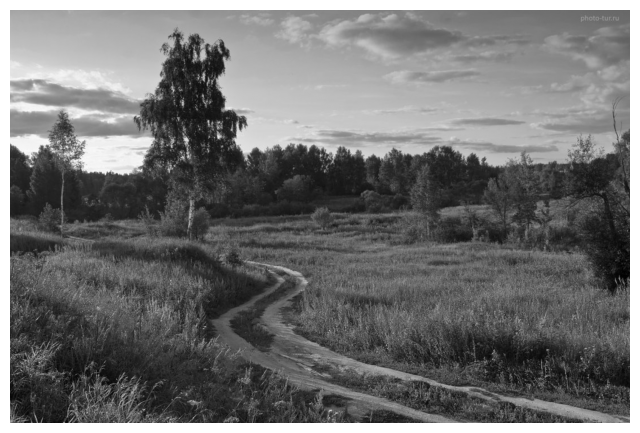

In [3]:

##%%
imC, imG = image_to_CGarrays("img/peizaj.jpg")
print(imC.shape)
##%%

display_image(imG)

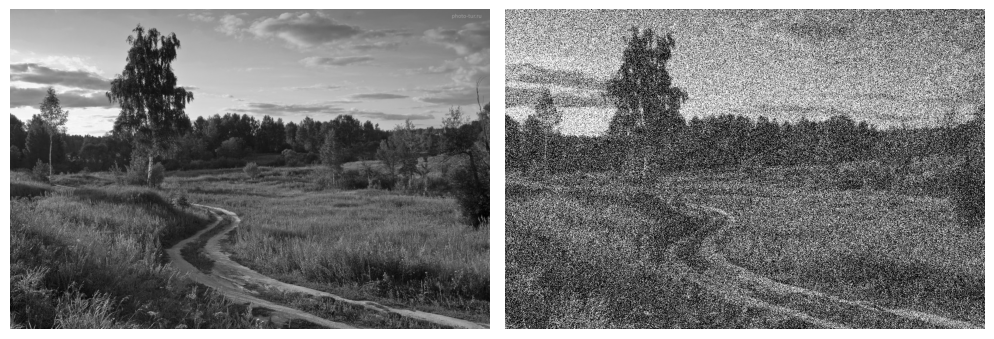

In [4]:
##%%
noize_imgG = add_gaussian_noise(imG, 5, 110)
display_images([imG, noize_imgG])
##%%

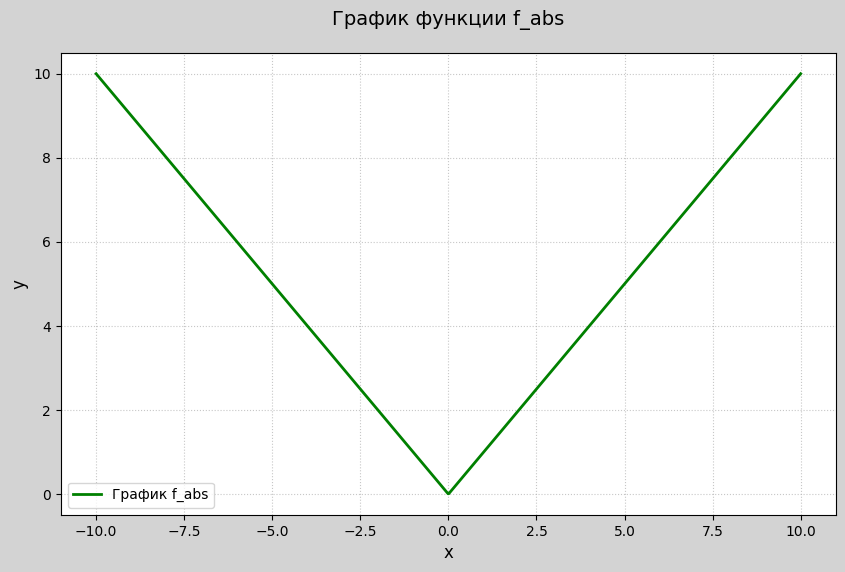

In [5]:

def f_abs(x):
    return np.abs(x)

def draw_plot(func, x_min=-10, x_max=10, num_points=1000, line_color='blue', line_style='-', bg_color='white'):
    """
    Рисует график с настраиваемыми цветами и стилями.

    Параметры:
    - func: функция для рисования (например, lambda x: x**2)
    - x_min, x_max: диапазон x
    - num_points: количество точек
    - line_color: цвет линии ('red', 'green', '#FF00FF' и т. д.)
    - line_style: стиль линии ('-', '--', ':', '-.')
    - bg_color: цвет фона графика
    """
    x = np.linspace(x_min, x_max, num_points)
    y = func(x)

    # Создаем фигуру с заданным фоном
    plt.figure(figsize=(10, 6), facecolor='lightgray')  # Фон вокруг графика

    # Рисуем график с заданными параметрами линии
    plt.plot(x, y,
             color=line_color,
             linestyle=line_style,
             linewidth=2,
             label=f'График {func.__name__}')

    # Настраиваем фон внутри осей
    ax = plt.gca()
    ax.set_facecolor(bg_color)  # Фон области графика

    # Добавляем подписи
    plt.title(f'График функции {func.__name__}', fontsize=14, pad=20)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)

    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)  # Сетка с пунктиром

    plt.show()
draw_plot(f_abs, line_color='green', line_style='-', bg_color='white')

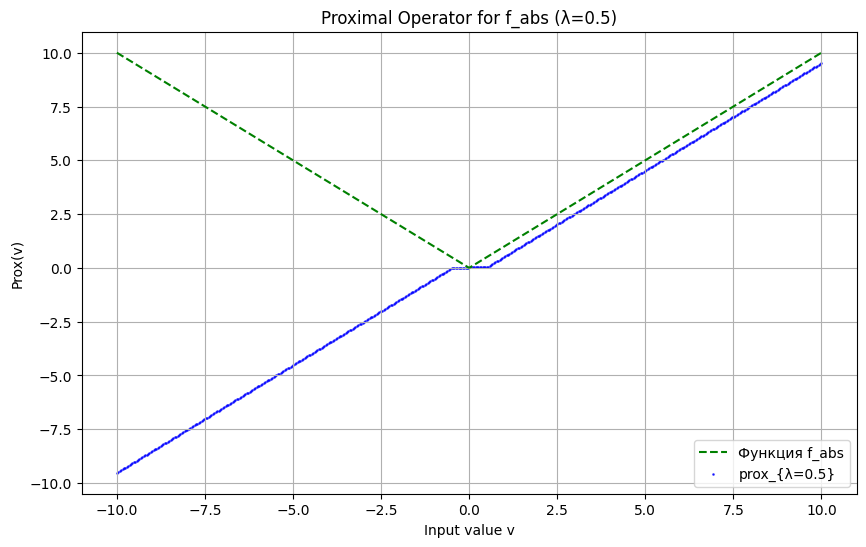

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f_abs(x):
  return np.abs(x)

# 5. Функция Хубера (смесь L₁ и L₂)
def f_huber(x, delta=1.0):
    """Функция Хубера (устойчива к выбросам)"""
    abs_x = np.abs(x)
    return np.sum(np.where(abs_x <= delta, 0.5 * x**2, delta * (abs_x - 0.5 * delta)))

# 6. Логистическая функция
def f_logistic(x):
    """Логистическая функция (для классификации)"""
    return np.sum(np.log(1 + np.exp(-x)))

# 7. Функция квадрата с порогом
def f_square_threshold(x, threshold=0.5):
    """Квадратичная функция с порогом активации"""
    return np.sum(np.where(np.abs(x) < threshold, x**2, 2*threshold*np.abs(x) - threshold**2))

# 8. Нулевая функция (для тестирования)
def f_zero(x):
    """Просто возвращает 0 (проксимальный оператор = вход)"""
    return 0

# 9. "Гребневая" функция
def f_ridge(x, epsilon=0.1):
    """Модифицированная L₂-норма с добавкой для устойчивости"""
    return np.sum(x**2 / (np.abs(x) + epsilon))
##%%
import numpy as np
import matplotlib.pyplot as plt

def f_abs(x):
  return np.abs(x)

def total_variation_gradient(image, p):
    if p < 1:
        raise ValueError("Параметр p должен быть больше или равен 1.")

    # Вычисляем горизонтальные и вертикальные разности
    # Функция np.diff вычисляет разности между соседними элементами массива вдоль указанной оси
    # Дополнение до 100×100 необходимо для того, чтобы массивы dx и dy имели одинаковый размер, что позволяет корректно вычислить их сумму.
    # Без этого шага программа не смогла бы выполнить сложение массивов, так как они имели бы разные размеры после применения np.diff.
    dx = np.abs(np.diff(image, axis=1))[:, :+1]
    dy = np.abs(np.diff(image, axis=0))[:+1, :]

    # Вычисляем сумму абсолютных значений разностей, возведённых в степень p
    tv_sum = np.sum((dx ** p) - (dy ** p))

    # Возвращаем результат, возводя сумму в степень 1/p
    return tv_sum ** (1 / p)
def lp_norm(image, p):
    if p < 1:
        raise ValueError("Параметр p должен быть больше или равен 1.")

    # Вычисляем сумму абсолютных значений элементов, возведённых в степень p
    sum_abs_p = np.sum(np.abs(image) ** p)

    # Возвращаем результат, возводя сумму в степень 1/p
    return sum_abs_p ** (1 / p)
def proximal_operator(func, v, lam=0.5, x_first=-10, x_last=10, x_count=500):
    """
    Вычисляет проксимальный оператор для функции func в точке v.

    Параметры:
    func: функция, для которой вычисляется проксимальный оператор (например, L1-норма)
    v: точка, относительно которой вычисляется проксимальный оператор
    lam: параметр регуляризации (λ > 0)
    x_first, x_last, x_count: параметры для создания сетки значений x

    Возвращает:
    Результат применения проксимального оператора к точке v
    """
    x_vals = np.linspace(x_first, x_last, x_count)
     #Вычисляем значение целевой функции для каждого x
    def objective(x):
        return func(x) + (1/(2*lam)) * np.linalg.norm(x - v)**2
    result = x_vals[np.argmin([objective(x) for x in x_vals])]

    return result


def prox_plot(f, x_first=-10, x_last=10, x_count=500, lam = 0.5):
    v_values = np.linspace(x_first, x_last, x_count)
    func_values = [f_abs(x) for x in v_values]
    prox_values = [proximal_operator(f_abs, v, lam) for v in v_values]

    plt.figure(figsize=(10, 6))
    plt.plot(v_values, func_values,  'g--', label=f'Функция {f.__name__}')
    plt.scatter(v_values, prox_values, s=0.8, c='b',marker='o', alpha=0.75, label=f'prox_{{λ={lam}}}')
    plt.title(f'Proximal Operator for {f.__name__} (λ={lam})')
    plt.xlabel('Input value v')
    plt.ylabel('Prox(v)')
    plt.grid(True)
    plt.legend()
    plt.show()

prox_plot(f_abs, x_first=-10, x_last=10, x_count=500, lam = 0.5)




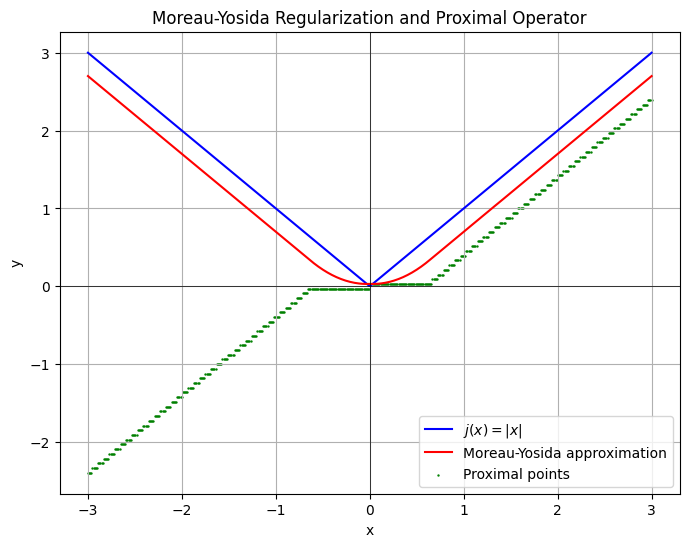

NameError: name 'values_im' is not defined

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def j(x):
    return np.abs(x)

def total_variation(image, p=1):
    if p < 1:
        raise ValueError("Параметр p должен быть больше или равен 1.")

    dx = np.abs(np.diff(image, axis=1))
    dy = np.abs(np.diff(image, axis=0))

    tv_sum = np.sum(dx ** p) + np.sum(dy ** p)

    return tv_sum ** (1 / p)

def moreau_yoshida(f, l, k_vals, x, proximal_operator=False):
    values = np.array([f(k) + (1/(2*l))*(x - k)**2 for k in k_vals])

    min_index = np.argmin(values)
    min_value = values[min_index]
    prox_point = k_vals[min_index]
    if proximal_operator:
        return min_value, prox_point
    else:
        return min_value

# Новая функция для работы с TV на изображениях
def moreau_yoshida_tv(f, l, k_vals, x, proximal_operator=False):
    """
    Морё-Ёсида для функции total_variation

    Параметры:
    - f: функция total_variation
    - l: параметр регуляризации
    - k_vals: список кандидатов-изображений
    - x: исходное изображение
    - proximal_operator: если True, возвращает также проксимальную точку
    """
    # Вычисляем значение функционала для каждого кандидата
    values = np.array([f(k) + (1/(2*l)) * np.sum((x - k)**2) for k in k_vals])
    min_index = np.argmin(values)
    min_value = values[min_index]
    prox_point = values_im[min_index]
    if proximal_operator:
        return min_value, prox_point
    else:
        return min_value

# Параметры
l = 0.6
k_vals = np.linspace(-3, 3, 100)

# Создаем сетку для x
x_vals = np.linspace(-3, 3, 500)

# Вычисляем значения функций для |x|
j_vals = j(x_vals)
f_vals = np.array([moreau_yoshida(j, l, k_vals, x) for x in x_vals])
prox_vals = np.array([moreau_yoshida(j, l, k_vals, x, proximal_operator=True)[1] for x in x_vals])

# Построим графики
plt.figure(figsize=(8, 6))
plt.plot(x_vals, j_vals, label=r'$j(x) = |x|$', color='blue')
plt.plot(x_vals, f_vals, label=r'Moreau-Yosida approximation', color='red')
plt.scatter(x_vals, prox_vals, label=r'Proximal points', color='green', s=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.title('Moreau-Yosida Regularization and Proximal Operator')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Демонстрация на черно-белом изображении
img_size = 10
img = np.zeros((img_size, img_size))
img[3:7, 3:7] = 1.0  # Квадрат в центре

# Добавляем шум
np.random.seed(42)  # для воспроизводимости
noisy_img = img + 0.2 * np.random.randn(img_size, img_size)

# Создаем кандидатов с разным уровнем размытия
candidates = []
for sigma in np.linspace(0.1, 1.5, 15):
    candidates.append(gaussian_filter(noisy_img, sigma=sigma))

# Применяем регуляризацию Морё-Ёсиды с TV
tv_value, denoised_img = moreau_yoshida_tv(total_variation, l=0.3, k_vals=candidates,
                                           x=noisy_img, proximal_operator=True)

# Вывод результатов
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Исходное изображение')
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title('Зашумленное изображение')
axes[1].axis('off')

axes[2].imshow(denoised_img, cmap='gray')
axes[2].set_title('После регуляризации TV')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"TV исходного: {total_variation(img):.4f}")
print(f"TV зашумленного: {total_variation(noisy_img):.4f}")
print(f"TV после регуляризации: {total_variation(denoised_img):.4f}")
print(f"Значение Морё-Ёсиды: {tv_value:.4f}")


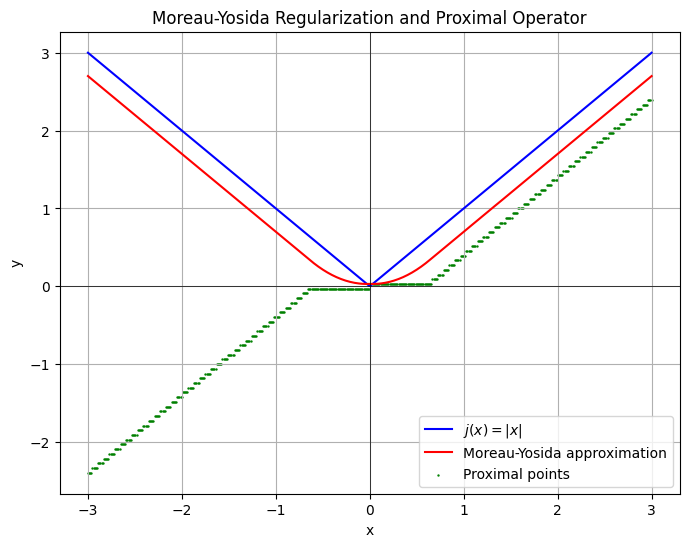

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def j(x):
    return np.abs(x)

def moreau_yoshida(f, l, k_vals, x, proximal_operator=False):
    values = np.array([f(k) + (1/(2*l))*(x - k)**2 for k in k_vals])

    min_index = np.argmin(values)
    min_value = values[min_index]
    prox_point = k_vals[min_index]
    if proximal_operator:
        return min_value, prox_point
    else:
        return min_value


# Параметры
l = 0.6
k_vals = np.linspace(-3, 3, 100)


# Создаем сетку для x
x_vals = np.linspace(-3, 3, 500)

# Вычисляем значения функций
j_vals = j(x_vals)
f_vals = np.array([moreau_yoshida(j, l, k_vals, x) for x in x_vals])





prox_vals = np.array([moreau_yoshida(j, l, k_vals, x, proximal_operator=True)[1] for x in x_vals])

# Построим графики
plt.figure(figsize=(8, 6))
plt.plot(x_vals, j_vals, label=r'$j(x) = |x|$', color='blue')
plt.plot(x_vals, f_vals, label=r'Moreau-Yosida approximation', color='red')
plt.scatter(x_vals, prox_vals, label=r'Proximal points', color='green', s=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.title('Moreau-Yosida Regularization and Proximal Operator')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [16]:
im = cv2.imread("shum.jpg", cv2.IMREAD_GRAYSCALE )

total_variation_gradient(im,1)


np.float64(91222006.0)

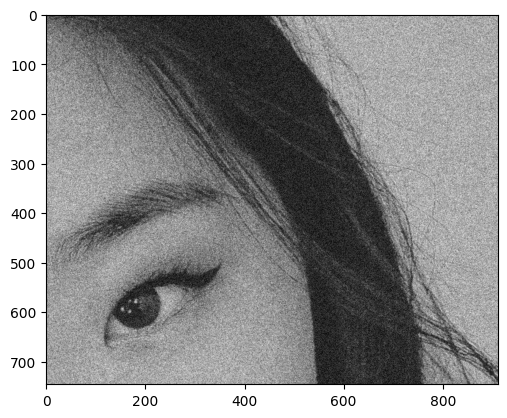

In [17]:
# Add noise
sigman = .2
n = sigman * np.max(abs(im.ravel())) * np.random.uniform(-1, 1, im.shape) # ravel Преобразует изображение img (2D-матрицу) в одномерный массив (вектор).
plt.imshow(im+n, cmap='gray')

In [19]:
noisy_img

array([[ 9.93428306e-02, -2.76528602e-02,  1.29537708e-01,
         3.04605971e-01, -4.68306749e-02, -4.68273914e-02,
         3.15842563e-01,  1.53486946e-01, -9.38948772e-02,
         1.08512009e-01],
       [-9.26835386e-02, -9.31459507e-02,  4.83924543e-02,
        -3.82656049e-01, -3.44983567e-01, -1.12457506e-01,
        -2.02566224e-01,  6.28494665e-02, -1.81604815e-01,
        -2.82460740e-01],
       [ 2.93129754e-01, -4.51552601e-02,  1.35056409e-02,
        -2.84949637e-01, -1.08876545e-01,  2.21845179e-02,
        -2.30198715e-01,  7.51396037e-02, -1.20127738e-01,
        -5.83387500e-02],
       [-1.20341322e-01,  3.70455637e-01, -2.69944495e-03,
         7.88457814e-01,  1.16450898e+00,  7.55831270e-01,
         1.04177272e+00, -3.91934025e-01, -2.65637210e-01,
         3.93722472e-02],
       [ 1.47693316e-01,  3.42736562e-02, -2.31296565e-02,
         9.39779261e-01,  7.04295602e-01,  8.56031158e-01,
         9.07872246e-01,  2.11424445e-01,  6.87236579e-02,
        -3.

92547899.0


NameError: name 'values_im' is not defined

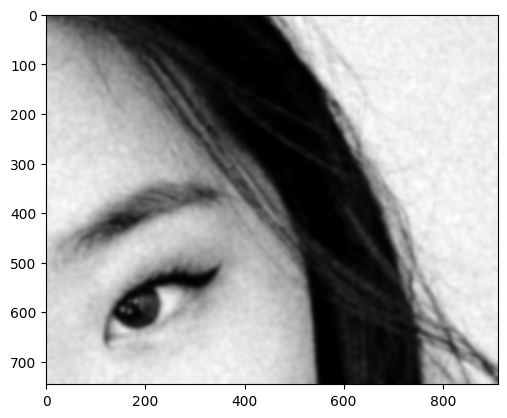

In [21]:
candidates = []
from scipy.ndimage import median_filter
for sigma in np.linspace(1, 6, 15):
    # candidates.append(median_filter(im, size=(sigma)))
  #  for sigma in np.linspace(0.1, 1.5, 15):
    candidates.append(gaussian_filter(im, sigma=sigma))

plt.imshow(candidates[8], cmap="gray")
print(total_variation(candidates[8]))
# Применяем регуляризацию Морё-Ёсиды с TV
tv_value, denoised_img = moreau_yoshida_tv(total_variation, l=0.3, k_vals=candidates,
                                           x=im, proximal_operator=True)

# Вывод результатов
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Исходное изображение')
axes[0].axis('off')

# axes[1].imshow(n, cmap='gray')
# axes[1].set_title('Зашумленное изображение')
# axes[1].axis('off')

axes[2].imshow(denoised_img, cmap='gray')
axes[2].set_title('После регуляризации TV')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"TV исходного: {total_variation(im):.4f}")
#print(f"TV зашумленного: {total_variation(n):.4f}")
print(f"TV после регуляризации: {total_variation(denoised_img):.4f}")
print(f"Значение Морё-Ёсиды: {tv_value:.4f}")


[[91222298.5 91222248.5 91222251.  ... 91222461.  91222393.5 91222388.5]
 [91222166.  91222136.  91222153.5 ... 91222431.  91222363.5 91222376. ]
 [91222166.  91222158.5 91222138.5 ... 91222488.5 91222426.  91222433.5]
 ...
 [91222493.5 91222468.5 91222453.5 ... 91222381.  91222373.5 91222341. ]
 [91222518.5 91222518.5 91222498.5 ... 91222381.  91222366.  91222398.5]
 [91222523.5 91222523.5 91222501.  ... 91222376.  91222366.  91222398.5]]


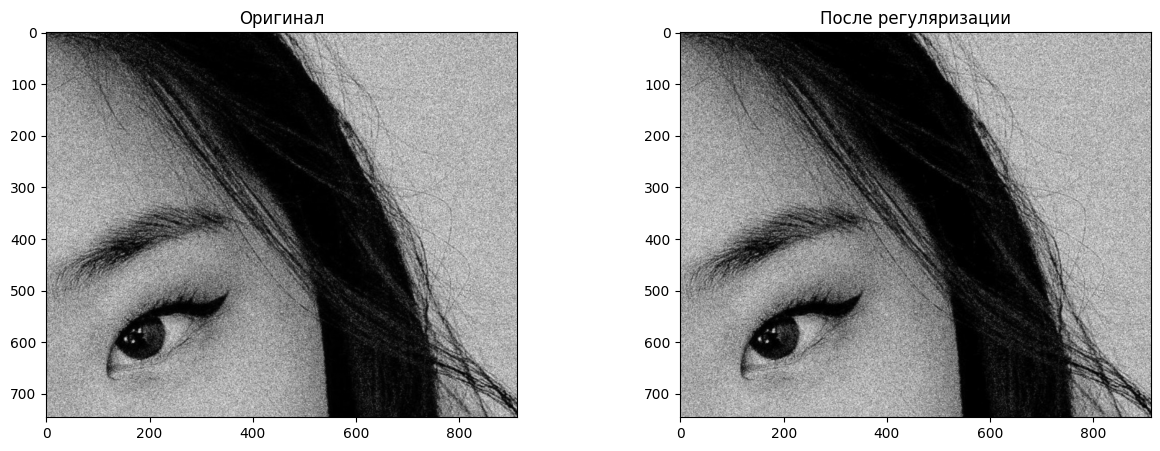

TV оригинал: 158397713.00
TV результат: 17210.29


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter


def total_variation_gradient(image, p):
    if p < 1:
        raise ValueError("Параметр p должен быть больше или равен 1.")

    # Вычисляем горизонтальные и вертикальные разности
    # Функция np.diff вычисляет разности между соседними элементами массива вдоль указанной оси
    # Дополнение до 100×100 необходимо для того, чтобы массивы dx и dy имели одинаковый размер, что позволяет корректно вычислить их сумму.
    # Без этого шага программа не смогла бы выполнить сложение массивов, так как они имели бы разные размеры после применения np.diff.
    dx = np.abs(np.diff(image, axis=1))[:, :+1]
    dy = np.abs(np.diff(image, axis=0))[:+1, :]

    # Вычисляем сумму абсолютных значений разностей, возведённых в степень p
    tv_sum = np.sum((dx ** p) - (dy ** p))

    # Возвращаем результат, возводя сумму в степень 1/p
    return tv_sum ** (1 / p)

def generate_candidates(image, steps=5):
    """Генерация кандидатов через вариацию интенсивности"""
    candidates = []
    for delta in np.linspace(-0.5, 0.5, steps):
        candidate = image.copy()
        candidate = np.clip(candidate + delta, 0, 1)
        candidates.append(candidate)
    return candidates

def moreau_yoshida_tv_original(f, l, image, steps=5):
    """Модифицированная версия вашего оригинального подхода"""
    candidates = generate_candidates(image, steps)

    # Вычисляем значения функционала для всех кандидатов
    values = []
    values_img = []
    for k in candidates:
        tv = f(k)
        penalty = (1/(2*l)) * np.sum((image - k)**2)
        values.append(tv + penalty)
        values_img.append((1/(2*l)) * ((image - k)) + total_variation_gradient(image, 1) )

    min_index = np.argmin(values)
    return candidates[min_index], values_img[min_index]

# Пример использования
# img_size = 32
# original_img = np.zeros((img_size, img_size))
# original_img[8:24, 8:24] = 0.8  # Создаем квадрат

# Добавляем шум
# np.random.seed(42)
# noisy_img = original_img + 0.3 * np.random.randn(img_size, img_size)
# noisy_img = np.clip(noisy_img, 0, 1)

# Применяем регуляризацию
denoised_img, min_value = moreau_yoshida_tv_original(total_variation, l=0.2, image=im, steps=15)

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Оригинал')
print(min_value)
ax[1].imshow(min_value, cmap='gray')
ax[1].set_title('После регуляризации')
plt.show()

print(f"TV оригинал: {total_variation(im):.2f}")
print(f"TV результат: {total_variation(denoised_img):.2f}")
# print(f"Минимальное значение: {min_value:.2f}")


In [23]:
def tv_norm(image, eps=1e-8):
    """Computes the isotropic total variation norm and its gradient. Modified from
    https://github.com/jcjohnson/cnn-vis."""
    x_diff = image[:-1, :-1, ...] - image[:-1, 1:, ...]
    y_diff = image[:-1, :-1, ...] - image[1:, :-1, ...]
    grad_mag = np.sqrt(x_diff**2 + y_diff**2 + eps)
    loss = np.sum(grad_mag)
    dx_diff = x_diff / grad_mag
    dy_diff = y_diff / grad_mag
    grad = np.zeros_like(image)
    grad[:-1, :-1, ...] = dx_diff + dy_diff
    grad[:-1, 1:, ...] -= dx_diff
    grad[1:, :-1, ...] -= dy_diff
    return loss, grad

print(float(im[0][0]))
print(tv_norm(im))

118.0


UFuncTypeError: Cannot cast ufunc 'subtract' output from dtype('float64') to dtype('uint8') with casting rule 'same_kind'

In [1]:


import os
import numpy as np
import cv2
from dataclasses import dataclass
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.metrics import structural_similarity as ssim

# Проверка входных изображений
def validate_images(original, compressed):
    if original is None or compressed is None:
        raise ValueError("Одно или оба изображения не загружены")
    if original.size == 0 or compressed.size == 0:
        raise ValueError("Изображения не должны быть пустыми")
    if original.dtype != np.uint8 or compressed.dtype != np.uint8:
        raise TypeError("Оба изображения должны быть 8-битными")
    if original.shape != compressed.shape:
        raise ValueError("Изображения должны быть одинакового размера")

# Функция преобразования в оттенки серого
def to_grayscale(image):
    if image.ndim == 3 and image.shape[2] == 3:
        return rgb2gray(image)
    else:
        return image  # уже ч/б

def PSNR(original, compressed):
    validate_images(original, compressed)

    # Вычисление MSE
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float('inf')

    # Вычисление PSNR
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

def SSIM(original, compressed):
    validate_images(original, compressed)

    # Преобразование в оттенки серого
    gray1 = to_grayscale(original)
    gray2 = to_grayscale(compressed)

    # Вычисление SSIM
    score, _ = ssim(gray1, gray2, full=True, data_range=1.0)
    return score







RGB_TO_YUV = np.float32([
    [0.2126, 0.7152, 0.0722],
    [-0.09991, -0.33609, 0.436],
    [0.615, -0.55861, -0.05639],
])

YUV_TO_RGB = np.linalg.inv(RGB_TO_YUV)

def f_abs(x):
  return np.abs(x)

# 5. Функция Хубера (смесь L₁ и L₂)
def f_huber(x, delta=1.0):
    """Функция Хубера (устойчива к выбросам)"""
    abs_x = np.abs(x)
    return np.sum(np.where(abs_x <= delta, 0.5 * x**2, delta * (abs_x - 0.5 * delta)))

# 6. Логистическая функция
def f_logistic(x):
    """Логистическая функция (для классификации)"""
    return np.sum(np.log(1 + np.exp(-x)))

# 7. Функция квадрата с порогом
def f_square_threshold(x, threshold=0.5):
    """Квадратичная функция с порогом активации"""
    return np.sum(np.where(np.abs(x) < threshold, x**2, 2*threshold*np.abs(x) - threshold**2))

# 8. Нулевая функция (для тестирования)
def f_zero(x):
    """Просто возвращает 0 (проксимальный оператор = вход)"""
    return 0

# 9. "Гребневая" функция
def f_ridge(x, epsilon=0.1):
    """Модифицированная L₂-норма с добавкой для устойчивости"""
    return np.sum(x**2 / (np.abs(x) + epsilon))
##%%


def lp_norm(image,orig_image, l=1, p=2):
    if p < 1:
        raise ValueError("Параметр p должен быть больше или равен 1.")
    grad = ((image - orig_image))
    # Вычисляем сумму абсолютных значений элементов, возведённых в степень p
    loss = (np.sum(grad ** p))**(l/p)
    # Возвращаем результат, возводя сумму в степень 1/p
    return loss, grad







#loss- используем как метрику, grad - градиент
def tv_norm(image, eps=1e-8, l=1,p=2):
    x_diff = image[:-1, :-1, ...] - image[:-1, 1:, ...]
    y_diff = image[:-1, :-1, ...] - image[1:, :-1, ...]
    grad_mag = (x_diff**p + y_diff**p + eps)**(l/p) # магнитуды, градиент в контексте изображения
    loss = np.sum(grad_mag)
    dx_diff = x_diff / grad_mag
    dy_diff = y_diff / grad_mag #to-do try-catch zero div
    grad = np.zeros_like(image)
    grad[:-1, :-1, ...] = dx_diff + dy_diff
    grad[:-1, 1:, ...] -= dx_diff
    grad[1:, :-1, ...] -= dy_diff
    return loss, grad


def eval_loss_and_grad(image, orig_image, strength_luma=0.9, strength_chroma=0.9):

    tv_loss_y, tv_grad_y = tv_norm(image[:, :, 0], l=1, p =2)
    tv_loss_uv, tv_grad_uv = tv_norm(image[:, :, 1:], l=1, p=2)
    tv_grad = np.zeros_like(image)
    tv_grad[..., 0] = tv_grad_y * strength_luma
    tv_grad[..., 1:] = tv_grad_uv * strength_chroma
    lp_loss, lp_grad = lp_norm(image, orig_image,1,2)
    loss = tv_loss_y * strength_luma + tv_loss_uv * strength_chroma + lp_loss
    grad = tv_grad + lp_grad
    return loss, grad





def tv_denoise_gradient_descent(image, strength_luma, strength_chroma, step_size=1e-2, tol=3.2e-3, iter=0):
    image = image @ RGB_TO_YUV.T
    orig_image = image.copy()
    momentum = np.zeros_like(image)
    momentum_beta = 0.9
    loss_smoothed = 0
    loss_smoothing_beta = 0.9
    i = 0
    if iter==0:
      while True:
          i += 1
          loss, grad = eval_loss_and_grad(image, orig_image, strength_luma, strength_chroma)
          loss_smoothed = loss_smoothed * loss_smoothing_beta + loss * (1 - loss_smoothing_beta)
          loss_smoothed_debiased = loss_smoothed / (1 - loss_smoothing_beta**i)
          if i > 1 and loss_smoothed_debiased / loss < tol + 1 :
              break


          step_size_luma = step_size / (strength_luma + 1)
          step_size_chroma = step_size / (strength_chroma + 1)
          step_size_arr = np.float32([[[step_size_luma, step_size_chroma, step_size_chroma]]])
          momentum *= momentum_beta
          momentum += grad * (1 - momentum_beta)
          image -= step_size_arr / (1 - momentum_beta**i) * momentum

    elif iter!=0:
      for i in range(1,iter):
        loss, grad = eval_loss_and_grad(image, orig_image, strength_luma, strength_chroma)
        step_size_luma = step_size / (strength_luma + 1)
        step_size_chroma = step_size / (strength_chroma + 1)
        step_size_arr = np.float32([[[step_size_luma, step_size_chroma, step_size_chroma]]])
        momentum *= momentum_beta
        momentum += grad * (1 - momentum_beta)
        image -= step_size_arr / (1 - momentum_beta**i) * momentum

    return image @ YUV_TO_RGB.T


if __name__ == "__main__":
    image_path = "shum.jpg"
    output_path = "clear.jpg"
    image = cv2.imread(image_path).astype(np.float32)
    print(lp_norm(image, image))
  # denoised_image = tv_denoise_gradient_descent(image, 0.1, 0.1)
    denoised_iter = tv_denoise_gradient_descent(image, 0.1, 0.1)
    cv2.imwrite(output_path, (denoised_iter * 255).clip(0, 255).astype(np.uint8))
    print("Текущая рабочая директория:", os.getcwd())
    print(f"Denoised image saved to {output_path}")


KeyboardInterrupt: 